# Part 3: NLP and Sequence Modeling Mini Project

This notebook builds a basic NLP pipeline for customer support sentiment classification. It covers dataset exploration, text cleaning, TF-IDF vectorization, a baseline classifier, and a simple GRU-based sequence model.

## Setup

In [1]:
import os
import re
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(1)

DATA_PATH = "data/customer_support_text_classification.csv"
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

## Task 1: Dataset Understanding

The dataset is loaded and explored to understand the number of records, columns, target classes, sample messages, text length, and class distribution.

In [2]:
df = pd.read_csv(DATA_PATH)
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1500, 6)


,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0
3,TKT00004,social,My refund is still pending and this experience...,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0


In [3]:
print("Columns:")
print(df.columns.tolist())

print()
print("Missing values:")
print(df.isna().sum())

print()
print("Target labels:")
print(df["sentiment_label"].value_counts())

Columns:
['ticket_id', 'channel', 'customer_message', 'sentiment_label', 'word_count', 'urgent_flag']

Missing values:
ticket_id           0
channel             0
customer_message    0
sentiment_label     0
word_count          0
urgent_flag         0
dtype: int64

Target labels:
sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64


In [4]:
print("Sample customer messages:")
for i, row in df[["customer_message", "sentiment_label"]].head(8).iterrows():
    print(f"{i+1}. [{row['sentiment_label']}] {row['customer_message']}")

Sample customer messages:
1. [neutral] I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.
2. [neutral] I need information about the payment process.
3. [positive] The refund process was fast and convenient. I appreciate the quick response.
4. [negative] My refund is still pending and this experience is frustrating. My ticket number is 33927.
5. [neutral] Please tell me how to update my account details.
6. [neutral] I need help finding the invoice for my last order. Please respond as soon as possible.
7. [positive] I am satisfied with the plan and would recommend it to others. My ticket number is 99198.
8. [neutral] I want to understand the warranty terms for this product.


In [5]:
df["raw_text_length"] = df["customer_message"].astype(str).str.split().apply(len)
print("Average text length in words:", round(df["raw_text_length"].mean(), 2))
print("Median text length in words:", round(df["raw_text_length"].median(), 2))
print("Minimum text length:", df["raw_text_length"].min())
print("Maximum text length:", df["raw_text_length"].max())

class_distribution = df["sentiment_label"].value_counts().rename_axis("sentiment_label").reset_index(name="count")
class_distribution["percentage"] = (class_distribution["count"] / len(df) * 100).round(2)
class_distribution

Average text length in words: 12.72
Median text length in words: 12.0
Minimum text length: 7
Maximum text length: 26


,sentiment_label,count,percentage
0,neutral,524,34.93
1,negative,497,33.13
2,positive,479,31.93


## Task 2: Text Preprocessing

The customer messages are cleaned before modeling. The preprocessing includes lowercasing, removing numbers and special characters, tokenization, and sequence padding/truncation for the GRU model.

Stopwords are not removed from the main cleaned text because words such as **not**, **no**, or **never** can change sentiment meaning. Removing them blindly can damage a sentiment classification task.

In [6]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["customer_message"].apply(clean_text)
df["tokens"] = df["clean_text"].str.split()
df["clean_text_length"] = df["tokens"].apply(len)

df[["customer_message", "clean_text", "tokens", "sentiment_label"]].head()

,customer_message,clean_text,tokens,sentiment_label
0,I need information about the payment process. ...,i need information about the payment process m...,"[i, need, information, about, the, payment, pr...",neutral
1,I need information about the payment process.,i need information about the payment process,"[i, need, information, about, the, payment, pr...",neutral
2,The refund process was fast and convenient. I ...,the refund process was fast and convenient i a...,"[the, refund, process, was, fast, and, conveni...",positive
3,My refund is still pending and this experience...,my refund is still pending and this experience...,"[my, refund, is, still, pending, and, this, ex...",negative
4,Please tell me how to update my account details.,please tell me how to update my account details,"[please, tell, me, how, to, update, my, accoun...",neutral


In [7]:
label_encoder = LabelEncoder()
df["label_id"] = label_encoder.fit_transform(df["sentiment_label"])

print("Label mapping:")
for label, idx in zip(label_encoder.classes_, range(len(label_encoder.classes_))):
    print(f"{label}: {idx}")

X_train, X_temp, y_train, y_temp = train_test_split(
    df["clean_text"],
    df["label_id"],
    test_size=0.30,
    random_state=SEED,
    stratify=df["label_id"]
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("Training records:", len(X_train))
print("Validation records:", len(X_val))
print("Testing records:", len(X_test))

Label mapping:
negative: 0
neutral: 1
positive: 2
Training records: 1050
Validation records: 225
Testing records: 225


## Task 3: Text Vectorization

Machine learning models cannot directly understand raw text. Text must first be converted into numbers.

This notebook uses two vectorization approaches:

1. **TF-IDF vectors** for the Logistic Regression baseline.
2. **Tokenizer-based padded sequences** for the GRU sequence model.

In [8]:
tfidf_vectorizer = TfidfVectorizer(max_features=2000, ngram_range=(1, 2))

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf = tfidf_vectorizer.transform(X_val)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("TF-IDF training matrix shape:", X_train_tfidf.shape)
print("TF-IDF validation matrix shape:", X_val_tfidf.shape)
print("TF-IDF testing matrix shape:", X_test_tfidf.shape)

TF-IDF training matrix shape: (1050, 569)
TF-IDF validation matrix shape: (225, 569)
TF-IDF testing matrix shape: (225, 569)


In [9]:
# Build vocabulary only from training data to avoid test leakage.
word_counter = Counter()
for text in X_train:
    word_counter.update(text.split())

MAX_VOCAB_SIZE = 1000
vocab = {"<PAD>": 0, "<UNK>": 1}
for word, count in word_counter.most_common(MAX_VOCAB_SIZE - 2):
    vocab[word] = len(vocab)

MAX_LEN = max(10, min(int(np.percentile(df["clean_text_length"], 95)), 50))

print("Vocabulary size:", len(vocab))
print("Maximum sequence length:", MAX_LEN)

def texts_to_sequences(texts, vocab, max_len):
    sequences = []
    for text in texts:
        token_ids = [vocab.get(token, vocab["<UNK>"]) for token in text.split()]
        token_ids = token_ids[:max_len]
        token_ids = token_ids + [vocab["<PAD>"]] * (max_len - len(token_ids))
        sequences.append(token_ids)
    return np.array(sequences, dtype=np.int64)

X_train_seq = texts_to_sequences(X_train, vocab, MAX_LEN)
X_val_seq = texts_to_sequences(X_val, vocab, MAX_LEN)
X_test_seq = texts_to_sequences(X_test, vocab, MAX_LEN)

print("Sequence training shape:", X_train_seq.shape)
print("Example sequence:", X_train_seq[0])

Vocabulary size: 183
Maximum sequence length: 19
Sequence training shape: (1050, 19)
Example sequence: [  2  32  54   3  41   6 161   0   0   0   0   0   0   0   0   0   0   0
   0]


## Task 4: Baseline Model

The baseline model uses TF-IDF vectorization with Logistic Regression. This is a strong first model for text classification because it is simple, fast, and interpretable.

In [10]:
baseline_model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)
baseline_model.fit(X_train_tfidf, y_train)

def evaluate_predictions(y_true, y_pred):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_weighted": precision,
        "recall_weighted": recall,
        "f1_weighted": f1
    }

baseline_train_pred = baseline_model.predict(X_train_tfidf)
baseline_val_pred = baseline_model.predict(X_val_tfidf)
baseline_test_pred = baseline_model.predict(X_test_tfidf)

baseline_metrics = {
    "Training": evaluate_predictions(y_train, baseline_train_pred),
    "Validation": evaluate_predictions(y_val, baseline_val_pred),
    "Testing": evaluate_predictions(y_test, baseline_test_pred)
}

baseline_metrics

{'Training': {'accuracy': 1.0,
  'precision_weighted': 1.0,
  'recall_weighted': 1.0,
  'f1_weighted': 1.0},
 'Validation': {'accuracy': 1.0,
  'precision_weighted': 1.0,
  'recall_weighted': 1.0,
  'f1_weighted': 1.0},
 'Testing': {'accuracy': 1.0,
  'precision_weighted': 1.0,
  'recall_weighted': 1.0,
  'f1_weighted': 1.0}}

In [11]:
print("Baseline Classification Report on Test Set:")
print(classification_report(y_test, baseline_test_pred, target_names=label_encoder.classes_, zero_division=0))

print("Baseline Confusion Matrix:")
print(confusion_matrix(y_test, baseline_test_pred))

Baseline Classification Report on Test Set:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        75
     neutral       1.00      1.00      1.00        78
    positive       1.00      1.00      1.00        72

    accuracy                           1.00       225
   macro avg       1.00      1.00      1.00       225
weighted avg       1.00      1.00      1.00       225

Baseline Confusion Matrix:
[[75  0  0]
 [ 0 78  0]
 [ 0  0 72]]


## Task 5: Sequence Model

The sequence model uses an embedding layer and a GRU recurrent layer. Unlike TF-IDF, this approach keeps the order of tokens in the input text.

Architecture:

- Input sequence: padded token IDs
- Embedding layer: converts token IDs into dense vectors
- GRU layer: processes the sequence in order
- Dense output layer: predicts one of the three sentiment classes
- Loss function: cross-entropy loss
- Evaluation metrics: accuracy, weighted precision, weighted recall, and weighted F1-score

In [12]:
train_dataset = TensorDataset(torch.tensor(X_train_seq), torch.tensor(y_train.values, dtype=torch.long))
val_dataset = TensorDataset(torch.tensor(X_val_seq), torch.tensor(y_val.values, dtype=torch.long))
test_dataset = TensorDataset(torch.tensor(X_test_seq), torch.tensor(y_test.values, dtype=torch.long))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=0)

class GRUTextClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.gru = nn.GRU(embedding_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(0.25)
        self.output = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        embedded = self.embedding(x)
        output, hidden = self.gru(embedded)
        last_hidden = hidden[-1]
        logits = self.output(self.dropout(last_hidden))
        return logits

sequence_model = GRUTextClassifier(
    vocab_size=len(vocab),
    embedding_dim=32,
    hidden_dim=32,
    num_classes=len(label_encoder.classes_)
)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weights = torch.tensor(class_weights, dtype=torch.float32)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(sequence_model.parameters(), lr=0.005)

sequence_model

GRUTextClassifier(
  (embedding): Embedding(183, 32, padding_idx=0)
  (gru): GRU(32, 32, batch_first=True)
  (dropout): Dropout(p=0.25, inplace=False)
  (output): Linear(in_features=32, out_features=3, bias=True)
)

In [13]:
def evaluate_sequence_model(model, data_loader):
    model.eval()
    losses = []
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for batch_x, batch_y in data_loader:
            logits = model(batch_x)
            loss = criterion(logits, batch_y)
            losses.append(loss.item())
            predictions = torch.argmax(logits, dim=1)
            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(batch_y.cpu().numpy())

    metrics = evaluate_predictions(np.array(all_labels), np.array(all_predictions))
    metrics["loss"] = float(np.mean(losses))
    return metrics, np.array(all_predictions), np.array(all_labels)

history = []
EPOCHS = 5

for epoch in range(1, EPOCHS + 1):
    sequence_model.train()
    train_losses = []

    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        logits = sequence_model(batch_x)
        loss = criterion(logits, batch_y)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    val_metrics, _, _ = evaluate_sequence_model(sequence_model, val_loader)
    history.append({
        "epoch": epoch,
        "train_loss": np.mean(train_losses),
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_f1_weighted": val_metrics["f1_weighted"]
    })

pd.DataFrame(history)

,epoch,train_loss,val_loss,val_accuracy,val_f1_weighted
0,1,1.048235,0.958680,0.484444,0.443046
1,2,0.667803,0.430955,0.777778,0.768578
2,3,0.418569,0.322746,0.862222,0.860643
3,4,0.177516,0.024156,1.000000,1.000000
4,5,0.018582,0.004713,1.000000,1.000000


In [14]:
sequence_train_metrics, sequence_train_pred, sequence_train_labels = evaluate_sequence_model(sequence_model, train_loader)
sequence_val_metrics, sequence_val_pred, sequence_val_labels = evaluate_sequence_model(sequence_model, val_loader)
sequence_test_metrics, sequence_test_pred, sequence_test_labels = evaluate_sequence_model(sequence_model, test_loader)

print("Sequence Model Classification Report on Test Set:")
print(classification_report(sequence_test_labels, sequence_test_pred, target_names=label_encoder.classes_, zero_division=0))

print("Sequence Model Confusion Matrix:")
print(confusion_matrix(sequence_test_labels, sequence_test_pred))

Sequence Model Classification Report on Test Set:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        75
     neutral       1.00      1.00      1.00        78
    positive       1.00      1.00      1.00        72

    accuracy                           1.00       225
   macro avg       1.00      1.00      1.00       225
weighted avg       1.00      1.00      1.00       225

Sequence Model Confusion Matrix:
[[75  0  0]
 [ 0 78  0]
 [ 0  0 72]]


## Model Comparison and Saved Outputs

The evaluation table compares the traditional TF-IDF baseline with the GRU sequence model. The required result files are saved inside the `results/` folder.

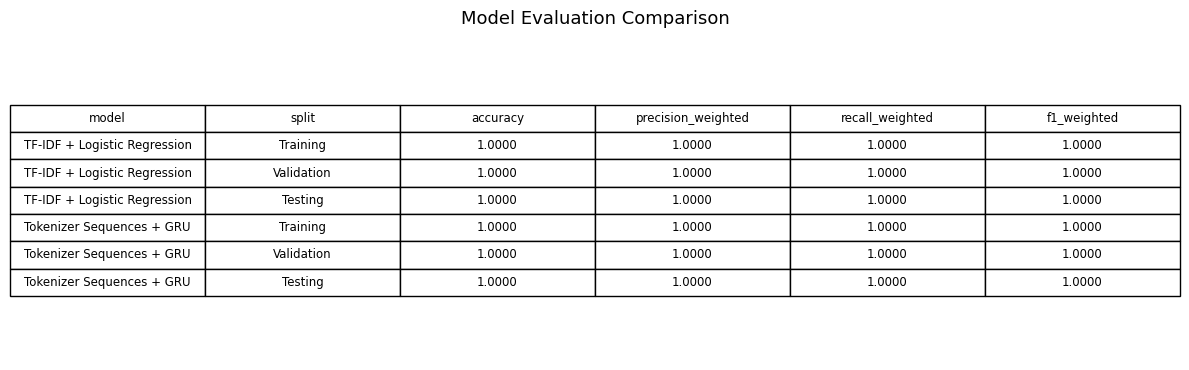

,model,split,accuracy,precision_weighted,recall_weighted,f1_weighted
0,TF-IDF + Logistic Regression,Training,1.0,1.0,1.0,1.0
1,TF-IDF + Logistic Regression,Validation,1.0,1.0,1.0,1.0
2,TF-IDF + Logistic Regression,Testing,1.0,1.0,1.0,1.0
3,Tokenizer Sequences + GRU,Training,1.0,1.0,1.0,1.0
4,Tokenizer Sequences + GRU,Validation,1.0,1.0,1.0,1.0
5,Tokenizer Sequences + GRU,Testing,1.0,1.0,1.0,1.0


In [15]:
evaluation_rows = []

for split_name, metrics in baseline_metrics.items():
    evaluation_rows.append({
        "model": "TF-IDF + Logistic Regression",
        "split": split_name,
        **metrics
    })

for split_name, metrics in [
    ("Training", sequence_train_metrics),
    ("Validation", sequence_val_metrics),
    ("Testing", sequence_test_metrics)
]:
    evaluation_rows.append({
        "model": "Tokenizer Sequences + GRU",
        "split": split_name,
        "accuracy": metrics["accuracy"],
        "precision_weighted": metrics["precision_weighted"],
        "recall_weighted": metrics["recall_weighted"],
        "f1_weighted": metrics["f1_weighted"]
    })

evaluation_df = pd.DataFrame(evaluation_rows)
evaluation_df = evaluation_df.round(4)

# The assignment allows model_evaluation as either .png or .csv.
# Here, it is saved as a PNG table to match the requested output format.
fig, ax = plt.subplots(figsize=(12, 3.8))
ax.axis("off")

display_df = evaluation_df.copy()
for col in ["accuracy", "precision_weighted", "recall_weighted", "f1_weighted"]:
    display_df[col] = display_df[col].map(lambda x: f"{x:.4f}")

table = ax.table(
    cellText=display_df.values,
    colLabels=display_df.columns,
    loc="center",
    cellLoc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(8.5)
table.scale(1, 1.5)
plt.title("Model Evaluation Comparison", fontsize=13, pad=12)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "model_evaluation.png"), dpi=200, bbox_inches="tight")
plt.show()

evaluation_df

In [16]:
# Save sample predictions from the baseline model.
sample_indices = list(X_test.index[:10])
sample_lines = []

for idx in sample_indices:
    original_text = df.loc[idx, "customer_message"]
    true_label = df.loc[idx, "sentiment_label"]
    vector = tfidf_vectorizer.transform([df.loc[idx, "clean_text"]])
    predicted_id = baseline_model.predict(vector)[0]
    predicted_label = label_encoder.inverse_transform([predicted_id])[0]
    sample_lines.append(
        "Text: " + original_text + chr(10) +
        "True label: " + true_label + chr(10) +
        "Predicted label: " + predicted_label + chr(10)
    )

sample_prediction_text = chr(10).join(sample_lines)
with open(os.path.join(RESULTS_DIR, "sample_predictions.txt"), "w", encoding="utf-8") as f:
    f.write(sample_prediction_text)

print(sample_prediction_text)

Text: Please tell me how to update my account details.
True label: neutral
Predicted label: neutral

Text: The refund process was fast and convenient. I appreciate the quick response.
True label: positive
Predicted label: positive

Text: I am satisfied with the plan and would recommend it to others. My ticket number is 67350.
True label: positive
Predicted label: positive

Text: The app crashes whenever I try to use profile update.
True label: negative
Predicted label: negative

Text: Please provide the steps to activate notifications. My ticket number is 20303.
True label: neutral
Predicted label: neutral

Text: The delivery was smooth and the product quality is excellent.
True label: positive
Predicted label: positive

Text: The refund process was fast and convenient. My ticket number is 41814.
True label: positive
Predicted label: positive

Text: The installation was completed on time and everything works perfectly.
True label: positive
Predicted label: positive

Text: Billing is in

## Task 6: Attention and Transformer Reflection

### Why RNNs struggle with long-term dependencies

RNNs process text one token at a time. This makes them useful for sequence data, but it also creates a problem when the important information appears far away from the point where the model has to make a prediction. As the model passes information through many time steps, earlier signals can become weaker. This is linked to the vanishing gradient problem, where the model struggles to update earlier parts of the sequence properly during training.

For example, in a long customer message, the customer may start with "I was disappointed" and then write several more neutral sentences. A basic RNN may not carry that early negative signal strongly enough until the final classification step.

### How LSTMs help with memory

LSTMs are designed to handle the memory problem better than simple RNNs. They use gates to control what information should be remembered, updated, or forgotten. The cell state works like a memory path, while the input, forget, and output gates decide how much information should move through the network.

This helps the model keep useful context over longer text sequences. In sentiment classification, an LSTM can retain important words or phrases from earlier in the message instead of relying only on the most recent tokens.

### What attention solves in sequence-to-sequence tasks

Attention helps a model focus on the most relevant parts of the input instead of forcing it to compress the entire sequence into one fixed-size vector. This is important in sequence-to-sequence tasks such as translation, summarization, and question answering.

For example, when generating an output word in translation, attention allows the model to look back at the input words that matter most for that specific output step. This gives the model a more flexible way to use context.

### Why transformers are important in modern NLP and Generative AI

Transformers are important because they use attention as the main mechanism for understanding relationships between tokens. Unlike RNNs, transformers do not have to process tokens strictly one after another. This makes them faster to train on large datasets and better at capturing long-range relationships in text.

Transformers are the foundation of many modern NLP and Generative AI systems because they scale well, handle context effectively, and can be adapted to many tasks such as classification, translation, summarization, text generation, and question answering.


## Final Interpretation

Both models perform strongly on this synthetic dataset because the sentiment classes contain clear keyword patterns. The TF-IDF baseline is simpler and easier to interpret, while the GRU model demonstrates the sequence-modeling idea by processing text in token order.

For a real customer support dataset, the problem would likely be harder because messages would contain spelling mistakes, sarcasm, mixed sentiment, and more varied language.